# Sequential Graph ♾️

## 🎯 Objective
- Create multiple `Nodes`
- Connect them sequentially in a graph
- Transform the state step-by-step

### Goal
Handle and update state using multiple connected `Nodes`.

---

# Exercise 3

## 📝 Task
Take:
- `name`
- `age`
- `skills`

Process them through 3 `Nodes`:

1. **Greeting Node** → Adds a personalized greeting  
2. **Age Node** → Describes the user's age  
3. **Skills Node** → Formats the skills list  

Combine all outputs into a final response.

---

## 💡 Example Output

```text
Hi Rakib, welcome to the system!
You are 30 years old.
You have skills in Python, Machine Learning, and LangGraph.
```

/home/rakib/miniconda3/envs/langgraph/lib/python3.13/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


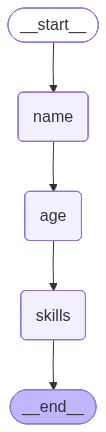

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
{
    "Final Result": {
        "name": "Rakib",
        "age": 30,
        "skills": [
            "Python",
            "Fastapi",
            "Django",
            "Machine Learning",
            "Deep Learning",
            "Langgraph"
        ],
        "result": "Hi Rakib, welcome to the system! You are 30 years old! You have skills in Python, Fastapi, Django, Machine Learning, Deep Learning and Langgraph."
    }
}
####################################################################################################


In [1]:
from typing import TypedDict, List
from langgraph.graph import StateGraph
from tools.VGraph import Helper

__tools__ = Helper()

class Agent3(TypedDict):
    name: str
    age: str
    skills: list[str]
    result: str


def name(state: Agent3) -> Agent3:
    state["result"] = f'Hi {state["name"]}, welcome to the system! '
    return state

def age(state: Agent3) -> Agent3:
    state["result"] += f'You are {state["age"]} years old! '
    return state

def skills(state: Agent3) -> Agent3:
    state["result"] += f"You have skills in {', '.join(state['skills'][:-1])} and {state['skills'][-1]}."
    return state

graph = StateGraph(Agent3)

graph.add_node("name", name)
graph.add_node("age", age)
graph.add_node("skills", skills)

graph.set_entry_point("name")
graph.add_edge("name","age")
graph.add_edge("age","skills")
graph.set_finish_point("skills")

app = graph.compile()

__tools__.view_graph(app)


result = app.invoke(
    {
        "name": "Rakib",
        "age": 30,
        "skills": ["Python", "Fastapi", "Django", "Machine Learning", "Deep Learning", "Langgraph"]
    }
)

__tools__.monitor({"Final Result": result})